# Análise exploratória — Fechamento Abril e Maio/2026

Entrada: `02-Referencias/fechamento2026Abril-Maio.xlsx` (consolidado ODBC/SAGI/ATUA/FOPA/Supply).

## Objetivos
1. Perfil dos **682** lançamentos do fechamento (abr/mai por `data_pagamento`).
2. Receitas vs despesas por divisão, filial e plano de contas.
3. Conferência de natureza **D/R** (CC `1.x`/`2.x` × conta `6–9`/`4–5`).
4. Destaques operacionais (credores, ativos nível 4, custeio).

## Saídas
- `outputs/tabelas/fechamento_abr_mai_2026_resumo.xlsx` — abas de resumo
- Gráficos em `outputs/figuras/fechamento_abr_mai_2026/`

Execute **Run All** a partir de `04-Notebooks/Fechamento`.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

NOTEBOOK_DIR = Path.cwd()
_candidatos_root = [
    NOTEBOOK_DIR / ".." / ".." / "02-Referencias",
    NOTEBOOK_DIR / ".." / "02-Referencias",
    Path("02-Referencias"),
]
REFS_DIR = next((p.resolve() for p in _candidatos_root if p.resolve().exists()), None)
if REFS_DIR is None:
    raise FileNotFoundError("Pasta 02-Referencias não encontrada.")

ROOT = REFS_DIR.parent
ARQUIVO_ENTRADA = REFS_DIR / "fechamento2026Abril-Maio.xlsx"
OUT_TAB = ROOT / "outputs" / "tabelas"
OUT_FIG = ROOT / "outputs" / "figuras" / "fechamento_abr_mai_2026"
OUT_TAB.mkdir(parents=True, exist_ok=True)
OUT_FIG.mkdir(parents=True, exist_ok=True)

if not ARQUIVO_ENTRADA.exists():
    raise FileNotFoundError(ARQUIVO_ENTRADA)

print(f"Entrada: {ARQUIVO_ENTRADA.resolve()}")
print(f"Tabelas: {OUT_TAB.resolve()}")
print(f"Figuras: {OUT_FIG.resolve()}")

Entrada: C:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\02-Referencias\fechamento2026Abril-Maio.xlsx
Tabelas: C:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\outputs\tabelas
Figuras: C:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\outputs\figuras\fechamento_abr_mai_2026


In [2]:
def col_por_prefixo(df: pd.DataFrame, prefixo: str) -> str:
    """Resolve colunas com encoding irregular do Excel (ex.: CUSTEIO)."""
    hits = [c for c in df.columns if str(c).upper().startswith(prefixo.upper())]
    if not hits:
        raise KeyError(f"Coluna com prefixo {prefixo!r} não encontrada.")
    return hits[0]


def natureza_cc(cod) -> str:
    if pd.isna(cod):
        return "?"
    s = str(cod).strip()
    if s.startswith("1."):
        return "D"
    if s.startswith("2."):
        return "R"
    return "?"


def natureza_pc(cod) -> str:
    if pd.isna(cod):
        return "?"
    s = str(cod).strip()
    if s and s[0] in "6789":
        return "D"
    if s and s[0] in "45":
        return "R"
    return "?"


def resumo_valor(serie: pd.Series) -> pd.Series:
    return pd.Series(
        {
            "qtd": serie.count(),
            "soma": serie.sum(),
            "media": serie.mean(),
            "mediana": serie.median(),
            "min": serie.min(),
            "max": serie.max(),
        }
    )


df = pd.read_excel(ARQUIVO_ENTRADA, sheet_name=0)
COL_CUSTEIO_ABS = col_por_prefixo(df, "CUSTEIO ABSOR")
COL_CUSTEIO_VAR = col_por_prefixo(df, "CUSTEIO VARI")
COL_DEPARA = col_por_prefixo(df, "DE-PARA")

for col in ("data_nf", "data_pagamento"):
    df[col] = pd.to_datetime(df[col], errors="coerce")

df["mes_nf"] = df["data_nf"].dt.to_period("M").astype(str)
df["mes_pag"] = df["data_pagamento"].dt.to_period("M").astype(str)
df["nat_cc"] = df["n1_cod_centro_custo"].map(natureza_cc)
df["nat_pc"] = df["cod_conta"].map(natureza_pc)
df["nat_ok"] = df["nat_cc"] == df["nat_pc"]
df["tipo_fluxo"] = np.where(
    df["valor_conta"] > 0,
    "receita",
    np.where(df["valor_conta"] < 0, "despesa", "zero"),
)
df["abs_valor_conta"] = df["valor_conta"].abs()

display(Markdown(f"**{len(df):,}** linhas × **{len(df.columns)}** colunas"))
display(df.dtypes.to_frame("dtype"))
df.head(3)

**682** linhas × **42** colunas

,dtype
id,float64
sdssds,str
n1_cod_centro_custo,float64
n1_centro_custo,str
n1_CC,str
n2_cod_centro_custo,str
n2_centro_custo,str
n2_CC,str
n3_cod_centro_custo,str
n3_centro_custo,str


,id,sdssds,n1_cod_centro_custo,n1_centro_custo,n1_CC,n2_cod_centro_custo,n2_centro_custo,n2_CC,n3_cod_centro_custo,n3_centro_custo,n3_CC,n4_cod_centro_custo,n4_centro_custo,n4_CC,cod_conta,conta,cod_conta-descr,filial,titulo,valor_nf,...,observacao,data_nf,data_pagamento,cod_credor_forn_cli_func,credor_forn_cli_func,Origem,Sistema,Dados auxiliares,Valor Oficial,DE-PARA1,CUSTEIO ABSORÇÃO,CUSTEIO VARIÁVEL,VG_BCBI+,mes_nf,mes_pag,nat_cc,nat_pc,nat_ok,tipo_fluxo,abs_valor_conta
0,"1,979.00",SELETIVA,1.20,SELETIVA,1.2 SELETIVA,1.2.5,PRESIDENTE PRUDENTE,1.2.5 PRESIDENTE PRUDENTE,1.2.5.6,VEICULOS,1.2.5.6 VEICULOS,1.2.5.6.2,BZG6A91,1.2.5.6.2 BZG6A91,7.1.2,MANUTENÇÃO DE VEÍCULOS/MAQUINAS,7.1.2 MANUTENÇÃO DE VEÍCULOS/MAQUINAS,G&S PRUDENTE,NFE-71425,"9,104.24",...,\nCRISTINA - NFE. 71.425 VENC. 05/03/26 R$4.5...,2026-02-06,2026-04-06,15502,CAIADO PNEUS LTDA,Saída (Aplicações),SAGI,-,"-4,552.12",4.03.03 CUSTO COM MANUTENÇÃO DE VEÍCULOS/MÁQUINAS,4.03 CUSTO DE MÃO-DE-OBRA INDIRETA,4.02 CUSTO VARIÁVEL,03. GASTO VARIÁVEL,2026-02,2026-04,D,D,True,despesa,"4,552.12"
1,"1,980.00",EKIPA LOCACOES E SERV G&S,1.70,EKIPA LOCACOES E SERV G&S,1.7 EKIPA LOCACOES E SERV G&S,1.7.1,CONTRATOS,1.7.1 CONTRATOS,1.7.1.8,TUPY - JOINVILLE/SC,1.7.1.8 TUPY - JOINVILLE/SC,1.7.1.8.2,EHH0044,1.7.1.8.2 EHH0044,7.1.2,MANUTENÇÃO DE VEÍCULOS/MAQUINAS,7.1.2 MANUTENÇÃO DE VEÍCULOS/MAQUINAS,G3S PRUDENTE,NFE-101910,288.30,...,CRISTINA - NFE. 101.910 VENC. 15/02/26 VIA CA...,2026-01-29,2026-05-15,30885,PREMIUM COMERCIAL LTDA,Saída (Aplicações),SAGI,-,-48.05,4.03.03 CUSTO COM MANUTENÇÃO DE VEÍCULOS/MÁQUINAS,4.03 CUSTO DE MÃO-DE-OBRA INDIRETA,4.02 CUSTO VARIÁVEL,03. GASTO VARIÁVEL,2026-01,2026-05,D,D,True,despesa,48.05
2,"1,984.00",SELETIVA,1.20,SELETIVA,1.2 SELETIVA,1.2.5,PRESIDENTE PRUDENTE,1.2.5 PRESIDENTE PRUDENTE,1.2.5.1,ADMINISTRATIVO,1.2.5.1 ADMINISTRATIVO,1.2.5.1,ADMINISTRATIVO,1.2.5.1 ADMINISTRATIVO,7.5.13,SEGUROS,7.5.13 SEGUROS,G3S PRUDENTE,SEG2026105,"2,839.66",...,REF. A RENOVAÇÃO DE SEGURO ESCRITORIO SELETIV...,2026-02-13,2026-05-21,6849,HDI SEGUROS S/A,Saída (Aplicações),SAGI,-,-473.27,4.08.19 DESPESA COM SEGUROS,4.08 DESPESA OPERACIONAL,4.03 DESPESA FIXA,02. GASTO FIXO,2026-02,2026-05,D,D,True,despesa,473.27


## 1. Visão geral dos valores

No fechamento, `valor_conta` costuma vir **negativo para despesas** e **positivo para receitas**. A soma líquida aproxima o resultado do período na base exportada.

In [3]:
metricas = pd.DataFrame(
    {
        "valor_conta": resumo_valor(df["valor_conta"]),
        "valor_nf": resumo_valor(df["valor_nf"]),
        "valor_pago": resumo_valor(df["valor_pago"]),
    }
).T
display(metricas)

display(Markdown("### Fluxo por sinal de `valor_conta`"))
fluxo = (
    df.groupby("tipo_fluxo", observed=True)
    .agg(qtd=("id", "count"), soma=("valor_conta", "sum"), media=("valor_conta", "mean"))
    .sort_values("soma", ascending=False)
)
display(fluxo)

display(Markdown("### Período das datas"))
periodo = pd.DataFrame(
    {
        "campo": ["data_nf", "data_pagamento"],
        "min": [df["data_nf"].min(), df["data_pagamento"].min()],
        "max": [df["data_nf"].max(), df["data_pagamento"].max()],
    }
)
display(periodo)

nulos = df[["filial", "titulo", "observacao", "credor_forn_cli_func"]].isna().sum()
display(Markdown("### Campos com nulos"))
display(nulos[nulos > 0])

,qtd,soma,media,mediana,min,max
valor_conta,682.00,"9,176,358.33","13,455.07","-7,520.43","-52,645.60","6,004,014.74"
valor_nf,682.00,"20,337,607.41","29,820.54","7,287.66","-52,645.60","6,004,014.74"
valor_pago,682.00,"9,177,748.33","13,457.11","-7,520.43","-52,645.60","6,004,014.74"


### Fluxo por sinal de `valor_conta`

,qtd,soma,media
tipo_fluxo,,,
receita,9,"14,813,346.61","925,834.16"
zero,9,0.00,0.00
despesa,657,"-5,636,988.28","-8,579.89"


### Período das datas

,campo,min,max
0,data_nf,2026-01-07,2026-04-30
1,data_pagamento,2026-04-01,2026-05-27


### Campos com nulos

filial    2
dtype: int64

## 2. Abril vs Maio (referência de fechamento)

Corte principal: **`data_pagamento`** (pagamentos efetivos no fechamento abr/mai). Complemento: emissão NF (`data_nf`) — há lançamentos de meses anteriores pagos neste fechamento.

In [4]:
MES_FECHAMENTO = ["2026-04", "2026-05"]
df_fech = df[df["mes_pag"].isin(MES_FECHAMENTO)].copy()

por_mes_pag = (
    df_fech.groupby("mes_pag", observed=True)
    .agg(
        qtd=("id", "count"),
        soma_conta=("valor_conta", "sum"),
        soma_pago=("valor_pago", "sum"),
        receitas=("valor_conta", lambda s: s[s > 0].sum()),
        despesas=("valor_conta", lambda s: s[s < 0].sum()),
    )
    .sort_index()
)
display(Markdown("### Por mês de pagamento"))
display(por_mes_pag)

por_mes_nf = (
    df.groupby("mes_nf", observed=True)
    .agg(qtd=("id", "count"), soma_conta=("valor_conta", "sum"))
    .sort_index()
)
display(Markdown("### Por mês da NF (toda a base)"))
display(por_mes_nf)

for mes in MES_FECHAMENTO:
    sub = df_fech[df_fech["mes_pag"] == mes]
    display(Markdown(f"#### Top 8 contas — pagamento {mes}"))
    top_contas = (
        sub.groupby(["cod_conta", "conta"], observed=True)["valor_conta"]
        .agg(["count", "sum"])
        .sort_values("sum", key=abs, ascending=False)
        .head(8)
    )
    display(top_contas)

### Por mês de pagamento

,qtd,soma_conta,soma_pago,receitas,despesas
mes_pag,,,,,
2026-04,607,"9,855,920.38","9,857,310.38","14,763,346.61","-4,907,426.23"
2026-05,68,"-679,562.05","-679,562.05","50,000.00","-729,562.05"


### Por mês da NF (toda a base)

,qtd,soma_conta
mes_nf,,
2026-01,44,"-113,328.46"
2026-02,84,"-385,033.29"
2026-03,113,"-679,924.48"
2026-04,434,"10,354,644.56"


#### Top 8 contas — pagamento 2026-04

,,count,sum
cod_conta,conta,,
4.1.1,VENDAS DE SUCATAS,6,"13,031,629.13"
5.7.1,FRETES,200,"-2,172,884.39"
5.8.1,REVENDA DE MERCADORIA,1,"1,662,849.54"
6.6.1,FRETE DE TERCEIROS,200,"-1,516,673.97"
7.3.1,SALÁRIOS,89,"-656,772.67"
6.5.1,COMPRA P/ REVENDA,39,"-435,307.45"
5.4.11,RECEITAS DIVERSAS,1,"50,000.00"
7.1.2,MANUTENÇÃO DE VEÍCULOS/MAQUINAS,38,"-47,068.14"


#### Top 8 contas — pagamento 2026-05

,,count,sum
cod_conta,conta,,
7.3.1,SALÁRIOS,34,"-650,275.75"
5.4.11,RECEITAS DIVERSAS,1,"50,000.00"
6.5.3,COMPRA DE MAQUINAS E EQUIPAMENTOS,1,"-42,333.33"
8.4,CONSORCIO,1,"-13,555.50"
7.1.2,MANUTENÇÃO DE VEÍCULOS/MAQUINAS,9,"-10,166.61"
6.5.1,COMPRA P/ REVENDA,5,"-7,700.67"
7.5.6,MANUTENÇÕES E REPAROS - ESTRUTURA ADMINISTRATIVA,2,"-2,230.52"
7.5.13,SEGUROS,4,"-2,032.13"


## 3. Divisões (nível 1 e 2) e filiais

In [5]:
por_n1 = (
    df.groupby(["n1_cod_centro_custo", "n1_centro_custo", "nat_cc"], observed=True)
    .agg(qtd=("id", "count"), soma=("valor_conta", "sum"))
    .sort_values("soma", ascending=False)
)
display(Markdown("### Divisão nível 1 (n1)"))
display(por_n1)

por_n2 = (
    df.groupby(["n2_cod_centro_custo", "n2_centro_custo"], observed=True)
    .agg(qtd=("id", "count"), soma=("valor_conta", "sum"))
    .sort_values("soma", key=abs, ascending=False)
    .head(20)
)
display(Markdown("### Top 20 unidades nível 2 (|soma|)"))
display(por_n2)

por_filial = (
    df.groupby("filial", dropna=False, observed=True)
    .agg(qtd=("id", "count"), soma=("valor_conta", "sum"))
    .sort_values("soma", key=abs, ascending=False)
)
display(Markdown("### Por filial SAGI"))
display(por_filial.head(15))

cruz_filial_n1 = pd.crosstab(df["filial"], df["n1_centro_custo"], margins=True)
display(Markdown("### Matriz filial × divisão n1 (contagem)"))
display(cruz_filial_n1.iloc[:-1, :-1].head(12))

### Divisão nível 1 (n1)

qtd          soma
n1_cod_centro_custo n1_centro_custo           nat_cc                   
2.20                SELETIVA                  R         0 13,031,629.13
2.30                BRACOFER                  R         0  1,662,849.54
2.60                EKIPA LOCACOES RSE        R         2    100,000.00
1.80                RENDER LOCACOES           D         4     -2,878.88
1.50                EKIPA CONTEINER           D         2     -9,880.96
1.10                G3S ESCRITORIO            D         3    -43,818.30
                    PILARES                   D        19    -56,062.30
1.60                EKIPA LOCACOES RSE        D         4    -98,482.16
1.70                EKIPA LOCACOES E SERV G&S D        38   -374,750.94
1.30                BRACOFER                  D        84   -651,583.05
1.20                SELETIVA                  D       116   -654,833.02
1.40                TRANSMOVE GSL             D       203 -1,552,946.34
2.40                TRANSMOVE GSL             R       200 -2,172,884.39

### Top 20 unidades nível 2 (|soma|)

,,qtd,soma
n2_cod_centro_custo,n2_centro_custo,,
2.2.4,MARINGA,0,"6,004,014.74"
2.2.5,PRESIDENTE PRUDENTE,0,"2,182,261.80"
2.3.1,PRESIDENTE PRUDENTE,0,"1,662,849.54"
2.2.2,DOURADOS,0,"1,572,848.41"
2.2.3,LONDRINA,0,"1,489,192.13"
2.4.1,PRESIDENTE PRUDENTE,118,"-1,378,293.76"
2.2.7,CAMPO GRANDE,0,"1,033,737.20"
1.4.1,PRESIDENTE PRUDENTE,121,"-996,882.04"
2.2.8,MARINGA CIDADE ALTA,0,"749,574.85"


### Por filial SAGI

,qtd,soma
filial,,
G3S MARINGA,11,"5,884,634.69"
GSL PRUDENTE,236,"-2,338,903.43"
G3S PRUDENTE,48,"2,008,165.21"
G3S DOURADOS,14,"1,481,518.52"
G3S LONDRINA,6,"1,421,993.25"
G3S FILIAL 5,58,"1,211,023.52"
GSL MARINGA,124,"-1,154,895.60"
G3S CAMPO GRANDE,13,"978,070.11"
G3S CIDADE ALTA,3,"734,323.86"


### Matriz filial × divisão n1 (contagem)

n1_centro_custo,BRACOFER,EKIPA CONTEINER,EKIPA LOCACOES E SERV G&S,EKIPA LOCACOES RSE,G3S ESCRITORIO,PILARES,RENDER LOCACOES,SELETIVA,TRANSMOVE GSL
filial,,,,,,,,,
BRACOFER,21,0,0,0,0,0,0,0,0
G&S BARUERI,0,0,15,0,0,0,0,0,0
G&S CAMPO GRANDE,0,0,3,0,0,0,0,0,0
G&S DOURADOS,0,0,3,0,0,0,0,11,0
G&S LONDRINA,0,0,2,0,0,0,0,1,0
G&S MARINGA,0,0,3,0,0,0,0,3,0
G&S PRUDENTE,3,0,10,1,0,0,0,12,3
G3S ADM,0,0,0,0,3,8,0,7,0
G3S CAMPO GRANDE,0,0,0,0,0,5,0,9,0


## 4. Plano de contas e consistência D/R

In [6]:
por_conta = (
    df.groupby(["cod_conta", "conta", "nat_pc"], observed=True)
    .agg(qtd=("id", "count"), soma=("valor_conta", "sum"))
    .sort_values("soma", key=abs, ascending=False)
)
display(Markdown("### Contas (ordenado por |soma|)"))
display(por_conta.head(25))

invertidos = df[~df["nat_ok"] & (df["nat_cc"] != "?") & (df["nat_pc"] != "?")]
display(Markdown(f"### Cruzamentos CC×PC invertidos: **{len(invertidos)}**"))
if len(invertidos):
    display(
        invertidos[
            [
                "filial",
                "n1_CC",
                "cod_conta",
                "conta",
                "valor_conta",
                "titulo",
                "data_pagamento",
            ]
        ].head(20)
    )

receitas = df[df["tipo_fluxo"] == "receita"].sort_values("valor_conta", ascending=False)
display(Markdown("### Maiores receitas (`valor_conta` > 0)"))
display(
    receitas[
        [
            "filial",
            "n2_CC",
            "cod_conta",
            "conta",
            "valor_conta",
            "credor_forn_cli_func",
            "data_pagamento",
        ]
    ].head(12)
)

despesas = df[df["tipo_fluxo"] == "despesa"].sort_values("valor_conta")
display(Markdown("### Maiores despesas (`valor_conta` < 0)"))
display(
    despesas[
        [
            "filial",
            "n2_CC",
            "cod_conta",
            "conta",
            "valor_conta",
            "credor_forn_cli_func",
            "data_pagamento",
        ]
    ].head(15)
)

### Contas (ordenado por |soma|)

,,,qtd,soma
cod_conta,conta,nat_pc,,
4.1.1,VENDAS DE SUCATAS,R,0,"13,031,629.13"
5.7.1,FRETES,R,200,"-2,172,884.39"
5.8.1,REVENDA DE MERCADORIA,R,0,"1,662,849.54"
6.6.1,FRETE DE TERCEIROS,D,200,"-1,516,673.97"
7.3.1,SALÁRIOS,D,123,"-1,307,048.42"
6.5.1,COMPRA P/ REVENDA,D,44,"-443,008.12"
5.4.11,RECEITAS DIVERSAS,R,2,"100,000.00"
6.5.3,COMPRA DE MAQUINAS E EQUIPAMENTOS,D,2,"-84,666.66"
7.1.2,MANUTENÇÃO DE VEÍCULOS/MAQUINAS,D,47,"-57,234.75"


### Cruzamentos CC×PC invertidos: **0**

### Maiores receitas (`valor_conta` > 0)

,filial,n2_CC,cod_conta,conta,valor_conta,credor_forn_cli_func,data_pagamento
677,G3S MARINGA,2.2.4 MARINGA,4.1.1,VENDAS DE SUCATAS,"6,004,014.74",-,2026-04-30
680,G3S PRUDENTE,2.2.5 PRESIDENTE PRUDENTE,4.1.1,VENDAS DE SUCATAS,"2,182,261.80",-,2026-04-30
675,G3S FILIAL 5,2.3.1 PRESIDENTE PRUDENTE,5.8.1,REVENDA DE MERCADORIA,"1,662,849.54",CLIENTES,2026-04-30
679,G3S DOURADOS,2.2.2 DOURADOS,4.1.1,VENDAS DE SUCATAS,"1,572,848.41",-,2026-04-30
678,G3S LONDRINA,2.2.3 LONDRINA,4.1.1,VENDAS DE SUCATAS,"1,489,192.13",-,2026-04-30
676,G3S CAMPO GRANDE,2.2.7 CAMPO GRANDE,4.1.1,VENDAS DE SUCATAS,"1,033,737.20",-,2026-04-30
681,G3S CIDADE ALTA,2.2.8 MARINGA CIDADE ALTA,4.1.1,VENDAS DE SUCATAS,"749,574.85",-,2026-04-30
4,RSE,"2.6.3 VEICULO, MAQUINA E EQUIPAMENTO",5.4.11,RECEITAS DIVERSAS,"50,000.00",BRUNO INDUSTRIAL LTDA,2026-05-03
11,RSE,"2.6.3 VEICULO, MAQUINA E EQUIPAMENTO",5.4.11,RECEITAS DIVERSAS,"50,000.00",BRUNO INDUSTRIAL LTDA,2026-04-03
142,G3S FILIAL 5,1.3.1 PRESIDENTE PRUDENTE,6.5.1,COMPRA P/ REVENDA,"10,502.22",PERFIPAR MANUFATURADOS DE AÇO LTDA,2026-04-07


### Maiores despesas (`valor_conta` < 0)

,filial,n2_CC,cod_conta,conta,valor_conta,credor_forn_cli_func,data_pagamento
652,G3S PRUDENTE,1.2.5 PRESIDENTE PRUDENTE,7.3.1,SALÁRIOS,"-52,645.60",PROCESSAMENTO DE FOLHA,2026-05-08
650,G3S MARINGA,1.2.4 MARINGA DISTRITO,7.3.1,SALÁRIOS,"-50,884.61",PROCESSAMENTO DE FOLHA,2026-05-08
100,G3S FILIAL 5,1.3.1 PRESIDENTE PRUDENTE,6.5.1,COMPRA P/ REVENDA,"-46,816.65",07109439000104 - QUALY COM. E TRANSPORTES DE S...,2026-04-01
74,RSE,1.6.2 COMERCIAL,6.5.3,COMPRA DE MAQUINAS E EQUIPAMENTOS,"-42,333.33",MB CRUSHER DO BRASIL COMERCIO DE EQUIPAMENTOS ...,2026-04-20
78,RSE,1.6.2 COMERCIAL,6.5.3,COMPRA DE MAQUINAS E EQUIPAMENTOS,"-42,333.33",MB CRUSHER DO BRASIL COMERCIO DE EQUIPAMENTOS ...,2026-05-20
644,G3S ADM,1.2.1 CORPORATIVO SUCATA,7.3.1,SALÁRIOS,"-39,243.99",PROCESSAMENTO DE FOLHA,2026-05-08
112,G3S FILIAL 5,1.3.1 PRESIDENTE PRUDENTE,6.5.1,COMPRA P/ REVENDA,"-35,702.63",12884632000144 - GV DO BRASIL INDUSTRIA E COME...,2026-04-05
113,G3S FILIAL 5,1.3.1 PRESIDENTE PRUDENTE,6.5.1,COMPRA P/ REVENDA,"-35,702.61",12884632000144 - GV DO BRASIL INDUSTRIA E COME...,2026-04-15
97,G3S FILIAL 5,1.3.1 PRESIDENTE PRUDENTE,6.5.1,COMPRA P/ REVENDA,"-34,823.60",05477207000175 - AMAZON ACO INDUSTRIA E COMERC...,2026-04-28
96,G3S FILIAL 5,1.3.1 PRESIDENTE PRUDENTE,6.5.1,COMPRA P/ REVENDA,"-34,823.60",05477207000175 - AMAZON ACO INDUSTRIA E COMERC...,2026-04-20


## 5. Sistema de origem e credores

In [7]:
por_sistema = (
    df.groupby(["Sistema", "Origem"], observed=True)
    .agg(qtd=("id", "count"), soma=("valor_conta", "sum"))
    .sort_values("qtd", ascending=False)
)
display(Markdown("### Sistema × Origem"))
display(por_sistema)

por_credor = (
    df.groupby("credor_forn_cli_func", observed=True)
    .agg(qtd=("id", "count"), soma=("valor_conta", "sum"))
    .assign(abs_soma=lambda x: x["soma"].abs())
    .sort_values("abs_soma", ascending=False)
    .head(20)
)
display(Markdown("### Top 20 credores/fornecedores (|soma|)"))
display(por_credor)

### Sistema × Origem

qtd          soma
Sistema Origem                                
ATUA    Saida (Aplicacoes)   200 -2,172,884.39
        Saidas (Aplicacoes)  200 -1,516,673.97
FOPA    Saída (Aplicações)   123 -1,307,048.42
SAGI    Saída (Aplicações)    89   -168,992.54
Supply  Saída (Aplicações)    37   -429,369.21
        Saida (Aplicacoes)    21    -22,456.81
SAGI    Saida (Aplicacoes)     3       -695.00
        Entrada (Origem)       2 13,131,629.13
Supply  Entrada (Origem)       0  1,662,849.54

### Top 20 credores/fornecedores (|soma|)

,qtd,soma,abs_soma
credor_forn_cli_func,,,
-,0,"13,031,629.13","13,031,629.13"
CLIENTES,0,"1,662,849.54","1,662,849.54"
GERDAU ACOS LONGOS SA,127,"-1,435,966.02","1,435,966.02"
PROCESSAMENTO DE FOLHA,34,"-650,275.75","650,275.75"
GV DO BRASIL INDUSTRIA E COMERCIO DE ACO LTDA,42,"-558,238.60","558,238.60"
12884632000144 - GV DO BRASIL INDUSTRIA E COMERCIO DE ACO LTDA,4,"-135,828.74","135,828.74"
05477207000175 - AMAZON ACO INDUSTRIA E COMERCIO LTDA. AM,3,"-104,470.80","104,470.80"
BRUNO INDUSTRIAL LTDA,2,"100,000.00","100,000.00"
MB CRUSHER DO BRASIL COMERCIO DE EQUIPAMENTOS LTDA,2,"-84,666.66","84,666.66"


## 6. Custeio (absorção e variável)

In [8]:
por_abs = (
    df.groupby(COL_CUSTEIO_ABS, observed=True)
    .agg(qtd=("id", "count"), soma=("valor_conta", "sum"))
    .sort_values("soma", key=abs, ascending=False)
)
por_var = (
    df.groupby(COL_CUSTEIO_VAR, observed=True)
    .agg(qtd=("id", "count"), soma=("valor_conta", "sum"))
    .sort_values("soma", key=abs, ascending=False)
)
por_depara = (
    df.groupby(COL_DEPARA, observed=True)
    .agg(qtd=("id", "count"), soma=("valor_conta", "sum"))
    .sort_values("qtd", ascending=False)
    .head(15)
)

display(Markdown("### Custeio absorção"))
display(por_abs)
display(Markdown("### Custeio variável"))
display(por_var)
display(Markdown("### DE-PARA (top 15 por quantidade)"))
display(por_depara)

### Custeio absorção

,qtd,soma
CUSTEIO ABSORÇÃO,,
3.01 RECEITA OPERACIONAL BRUTA,0,"14,694,478.67"
3.02 RECEITA NÃO-OPERACIONAL,202,"-2,072,884.39"
4.01 CUSTO DA MERCADORIA VENDIDA,245,"-1,959,868.39"
4.02 CUSTO DE MÃO-DE-OBRA DIRETA,130,"-1,301,105.11"
4.08 DESPESA OPERACIONAL,17,"-93,886.96"
4.03 CUSTO DE MÃO-DE-OBRA INDIRETA,51,"-57,980.13"
4.07 DESPESA FINANCEIRA,1,"-13,555.50"
4.05 DESPESA COM PESSOAL,3,"-11,700.00"
4.04 DESPESA ADMINISTRATIVA,22,"-5,547.25"


### Custeio variável

,qtd,soma
CUSTEIO VARIÁVEL,,
3.01 RECEITA OPERACIONAL,0,"14,694,478.67"
3.02 RECEITA NÃO-OPERACIONAL,202,"-2,072,884.39"
4.02 CUSTO VARIÁVEL,296,"-2,017,848.52"
4.01 CUSTO FIXO,130,"-1,301,105.11"
4.03 DESPESA FIXA,18,"-103,651.40"
4.04 DESPESA VARIÁVEL,29,"-22,630.92"


### DE-PARA (top 15 por quantidade)

,qtd,soma
DE-PARA1,,
3.02.04 RECEITA COM FRETES,200,"-2,172,884.39"
4.01.07 CUSTO COM FRETES E CARRETOS,200,"-1,516,673.97"
4.02.01 CUSTO COM SALÁRIOS,128,"-1,300,418.81"
4.03.03 CUSTO COM MANUTENÇÃO DE VEÍCULOS/MÁQUINAS,47,"-57,234.75"
4.01.10 CUSTO COM COMPRA PARA REVENDA,44,"-443,008.12"
4.04.13 DESPESA COM MATERIAL DE INFORMÁTICA,8,-588.98
4.08.19 DESPESA COM SEGUROS,8,"-4,064.26"
4.03.01 CUSTO COM MANUTENÇÃO PÁTIO,4,-745.38
4.04.09 DESPESA COM INTERNET,4,-669.98


## 7. Ativos analíticos (nível 4 — placas / contratos)

In [9]:
tem_n4 = df["n4_cod_centro_custo"].notna() & (df["n4_cod_centro_custo"].astype(str).str.len() > 3)
df_n4 = df[tem_n4].copy()

display(Markdown(f"**{len(df_n4)}** lançamentos com centro de custo nível 4"))

por_n4 = (
    df_n4.groupby(["n4_cod_centro_custo", "n4_centro_custo", "n4_CC"], observed=True)
    .agg(qtd=("id", "count"), soma=("valor_conta", "sum"))
    .sort_values("soma")
    .head(20)
)
display(Markdown("### Top 20 ativos por despesa (soma mais negativa)"))
display(por_n4)

por_n4_conta = (
    df_n4.groupby(["n4_CC", "cod_conta", "conta"], observed=True)
    .agg(qtd=("id", "count"), soma=("valor_conta", "sum"))
    .sort_values("soma")
    .head(15)
)
display(Markdown("### Ativo × conta (maiores custos)"))
display(por_n4_conta)

**682** lançamentos com centro de custo nível 4

### Top 20 ativos por despesa (soma mais negativa)

,,,qtd,soma
n4_cod_centro_custo,n4_centro_custo,n4_CC,,
2.4.1.1,TRANSPORTE,2.4.1.1 TRANSPORTE,118,"-1,378,293.76"
1.4.1.1,TRANSPORTE,1.4.1.1 TRANSPORTE,118,"-960,609.67"
2.4.3.1,TRANSPORTE,2.4.3.1 TRANSPORTE,62,"-683,287.30"
1.3.1.2,COMERCIAL,1.3.1.2 COMERCIAL,51,"-502,371.49"
1.4.3.1,TRANSPORTE,1.4.3.1 TRANSPORTE,62,"-471,608.30"
1.2.5.3,OPERACIONAL,1.2.5.3 OPERACIONAL,21,"-122,399.57"
2.4.2.1,TRANSPORTE,2.4.2.1 TRANSPORTE,20,"-111,303.33"
1.2.4.3,OPERACIONAL,1.2.4.3 OPERACIONAL,7,"-97,820.12"
1.6.2,COMERCIAL,1.6.2 COMERCIAL,2,"-84,666.66"


### Ativo × conta (maiores custos)

,,,qtd,soma
n4_CC,cod_conta,conta,,
2.4.1.1 TRANSPORTE,5.7.1,FRETES,118,"-1,378,293.76"
1.4.1.1 TRANSPORTE,6.6.1,FRETE DE TERCEIROS,118,"-960,609.67"
2.4.3.1 TRANSPORTE,5.7.1,FRETES,62,"-683,287.30"
1.4.3.1 TRANSPORTE,6.6.1,FRETE DE TERCEIROS,62,"-471,608.30"
1.3.1.2 COMERCIAL,6.5.1,COMPRA P/ REVENDA,44,"-443,008.12"
1.2.5.3 OPERACIONAL,7.3.1,SALÁRIOS,8,"-115,035.26"
2.4.2.1 TRANSPORTE,5.7.1,FRETES,20,"-111,303.33"
1.2.4.3 OPERACIONAL,7.3.1,SALÁRIOS,7,"-97,820.12"
1.6.2 COMERCIAL,6.5.3,COMPRA DE MAQUINAS E EQUIPAMENTOS,2,"-84,666.66"


## 8. Gráficos

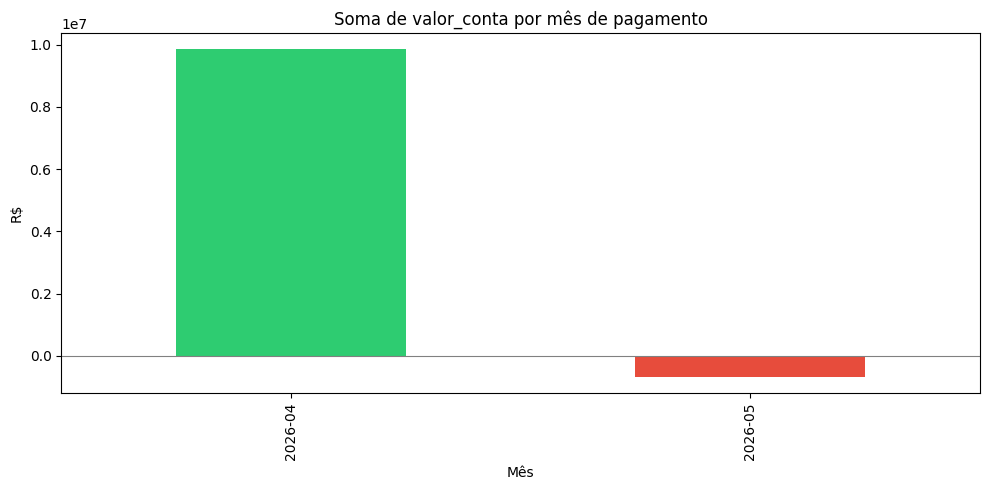

C:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\outputs\figuras\fechamento_abr_mai_2026\01_soma_por_mes_pagamento.png


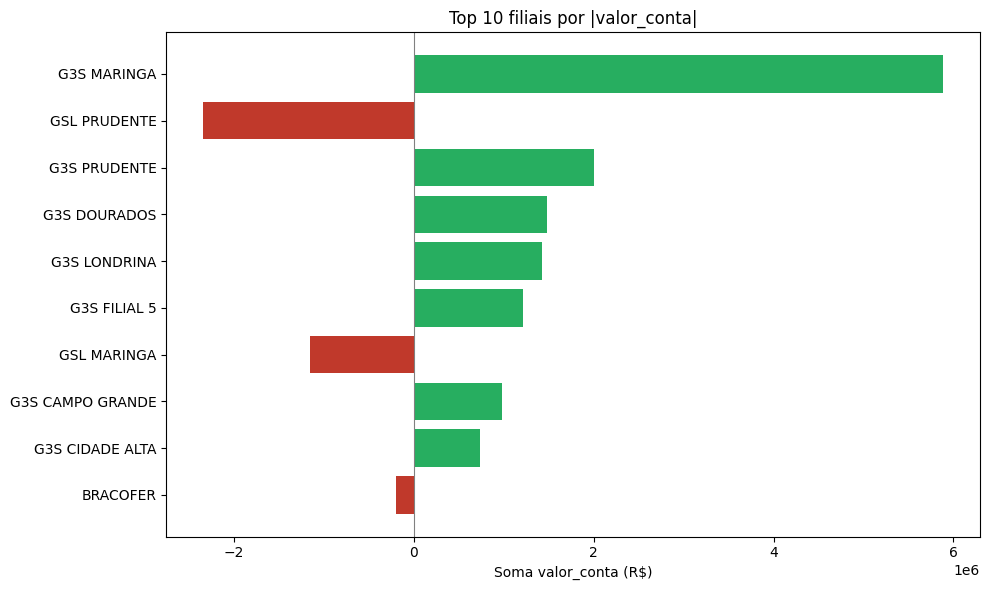

C:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\outputs\figuras\fechamento_abr_mai_2026\02_top_filiais.png


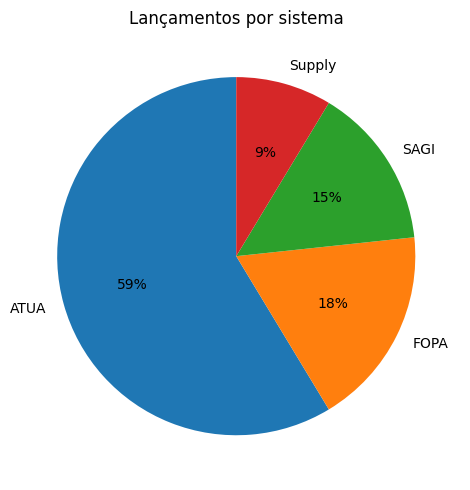

C:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\outputs\figuras\fechamento_abr_mai_2026\03_sistema_qtd.png


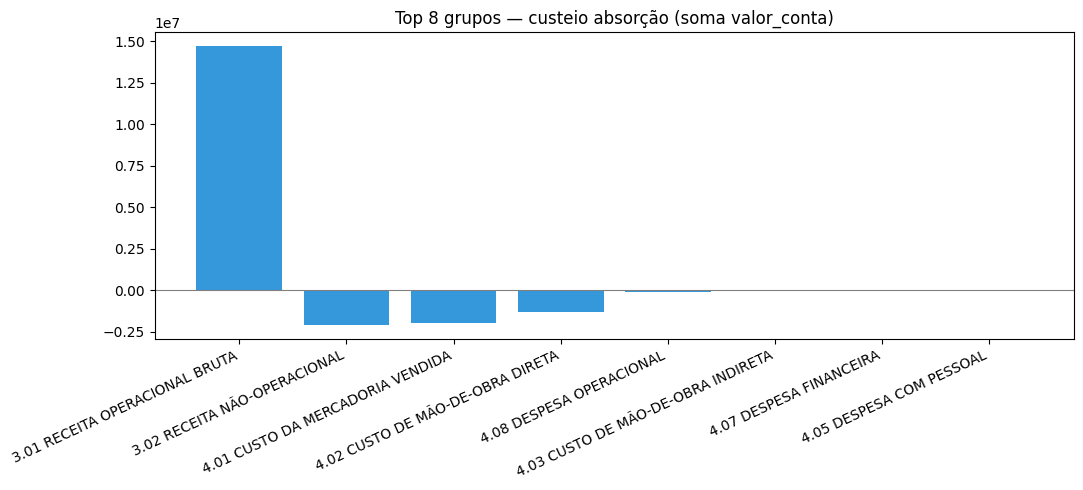

C:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\outputs\figuras\fechamento_abr_mai_2026\04_custeio_absorcao.png


In [10]:
plt.rcParams.update({"figure.figsize": (10, 5), "font.size": 10})

# 8.1 — Soma por mês de pagamento
fig, ax = plt.subplots()
por_mes_pag["soma_conta"].plot(kind="bar", ax=ax, color=["#2ecc71", "#e74c3c"])
ax.axhline(0, color="gray", lw=0.8)
ax.set_title("Soma de valor_conta por mês de pagamento")
ax.set_ylabel("R$")
ax.set_xlabel("Mês")
plt.tight_layout()
p1 = OUT_FIG / "01_soma_por_mes_pagamento.png"
fig.savefig(p1, dpi=120)
plt.show()
print(p1)

# 8.2 — Top 10 filiais (|soma|)
top_fil = por_filial.copy()
top_fil["abs"] = top_fil["soma"].abs()
top_fil = top_fil.sort_values("abs", ascending=True).tail(10)
fig, ax = plt.subplots(figsize=(10, 6))
cores = ["#27ae60" if v >= 0 else "#c0392b" for v in top_fil["soma"]]
ax.barh(top_fil.index.astype(str), top_fil["soma"], color=cores)
ax.axvline(0, color="gray", lw=0.8)
ax.set_title("Top 10 filiais por |valor_conta|")
ax.set_xlabel("Soma valor_conta (R$)")
plt.tight_layout()
p2 = OUT_FIG / "02_top_filiais.png"
fig.savefig(p2, dpi=120)
plt.show()
print(p2)

# 8.3 — Sistema (quantidade)
sis_qtd = df["Sistema"].value_counts()
fig, ax = plt.subplots()
sis_qtd.plot(kind="pie", ax=ax, autopct="%1.0f%%", startangle=90)
ax.set_ylabel("")
ax.set_title("Lançamentos por sistema")
plt.tight_layout()
p3 = OUT_FIG / "03_sistema_qtd.png"
fig.savefig(p3, dpi=120)
plt.show()
print(p3)

# 8.4 — Custeio absorção (soma)
top_abs = por_abs.head(8).copy()
fig, ax = plt.subplots(figsize=(11, 5))
labels = [str(i)[:40] for i in top_abs.index]
ax.bar(labels, top_abs["soma"], color="#3498db")
ax.axhline(0, color="gray", lw=0.8)
ax.set_title("Top 8 grupos — custeio absorção (soma valor_conta)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
p4 = OUT_FIG / "04_custeio_absorcao.png"
fig.savefig(p4, dpi=120)
plt.show()
print(p4)

## 9. Síntese executiva e exportação

In [11]:
total_rec = df.loc[df["valor_conta"] > 0, "valor_conta"].sum()
total_desp = df.loc[df["valor_conta"] < 0, "valor_conta"].sum()
liquido = df["valor_conta"].sum()

sintese = pd.DataFrame(
    {
        "indicador": [
            "Linhas na base",
            "Receitas (valor_conta > 0)",
            "Despesas (valor_conta < 0)",
            "Resultado líquido (soma valor_conta)",
            "Pagamentos abr/2026",
            "Pagamentos mai/2026",
            "Cruzamentos D/R invertidos",
            "Lançamentos com CC nível 4",
        ],
        "valor": [
            len(df),
            total_rec,
            total_desp,
            liquido,
            df_fech.loc[df_fech["mes_pag"] == "2026-04", "valor_conta"].sum(),
            df_fech.loc[df_fech["mes_pag"] == "2026-05", "valor_conta"].sum(),
            len(invertidos),
            len(df_n4),
        ],
    }
)
display(Markdown("### Painel resumido"))
display(sintese)

OUT_XLSX = OUT_TAB / "fechamento_abr_mai_2026_resumo.xlsx"
with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as w:
    sintese.to_excel(w, sheet_name="sintese", index=False)
    por_mes_pag.reset_index().to_excel(w, sheet_name="mes_pagamento", index=False)
    por_mes_nf.reset_index().to_excel(w, sheet_name="mes_nf", index=False)
    por_n1.reset_index().to_excel(w, sheet_name="divisao_n1", index=False)
    por_n2.reset_index().to_excel(w, sheet_name="divisao_n2_top20", index=False)
    por_filial.reset_index().to_excel(w, sheet_name="filiais", index=False)
    por_conta.reset_index().to_excel(w, sheet_name="contas", index=False)
    por_sistema.reset_index().to_excel(w, sheet_name="sistema_origem", index=False)
    por_credor.reset_index().to_excel(w, sheet_name="credores_top20", index=False)
    por_abs.reset_index().to_excel(w, sheet_name="custeio_absorcao", index=False)
    por_var.reset_index().to_excel(w, sheet_name="custeio_variavel", index=False)
    por_n4.reset_index().to_excel(w, sheet_name="ativos_n4_top20", index=False)
    if len(invertidos):
        invertidos.to_excel(w, sheet_name="alertas_dr", index=False)

print(f"Planilha exportada: {OUT_XLSX.resolve()}")

### Painel resumido

,indicador,valor
0,Linhas na base,682.00
1,Receitas (valor_conta > 0),"14,813,346.61"
2,Despesas (valor_conta < 0),"-5,636,988.28"
3,Resultado líquido (soma valor_conta),"9,176,358.33"
4,Pagamentos abr/2026,"9,855,920.38"
5,Pagamentos mai/2026,"-679,562.05"
6,Cruzamentos D/R invertidos,0.00
7,Lançamentos com CC nível 4,682.00


Planilha exportada: C:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\outputs\tabelas\fechamento_abr_mai_2026_resumo.xlsx
